In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import detrend

pa_gs = pd.read_csv('data/pa_data.csv')
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
east_pa_stations = pa_gs[pa_gs['longitude'] < 77.56]
west_pa_stations = pa_gs[pa_gs['longitude'] > 77.56]
elevation_over_400 = pa_gs[pa_gs['elevation_m'] > 400]
elevation_under_400 = pa_gs[pa_gs['elevation_m'] < 400]

In [63]:
def detrend_data(data_set, data_set_name, variable, detrend_deg, start_yr, end_yr):
    # Required Libraries: from scipy.signal import detrend, pandas as pd, matplotlib.pyplot as plt, numpy as np, seaborn as sns

    # Arguments:
        # data_set : name of dataframe with desired data for plotting
        # data_set_name : str; name of data subset for titles
        # variable : str; name of variable to plot on y axis
        # detrend_deg : str; 'linear' or 'constant' (see scipy.signal.detrend documentation for details)
        # start_yr: str; desired start of plot X axis
        #end_yr: str; desired end of plot X axis

    # Creates dataframe of yearly mean values of chosen variable in chosen years
    mean = data_set[['year', variable]].groupby('year').agg(['mean'])
    mean.columns = ['_'.join(col).strip() for col in mean.columns.values]
    mean = mean.reset_index()
    cols = ['year', variable]
    mean.columns = cols
    mean = mean[mean['year'].between(start_yr, end_yr)]
    

    #plots un-detrended data as a line plot
    sns.lineplot(data = mean, x='year', y=variable, errorbar= ('sd'))
    plt.xlabel('Year')
    plt.ylabel(f'Mean {data_set_name} {variable}')
    plt.title(f'Mean {data_set_name} {variable}, {start_yr}-{end_yr}')
    plt.show()

    #detrends data, plots detrended data as a line plot
    detrended_mean = detrend(mean[variable], type = detrend_deg)
    sns.lineplot(x=mean['year'], y= detrended_mean, errorbar=('sd'))
    plt.xlabel('Year')
    plt.ylabel(f'Detrended mean {data_set_name} {variable}')
    plt.title(f'Detrended Mean {data_set_name} {variable}, {start_yr}-{end_yr}')
    plt.show()

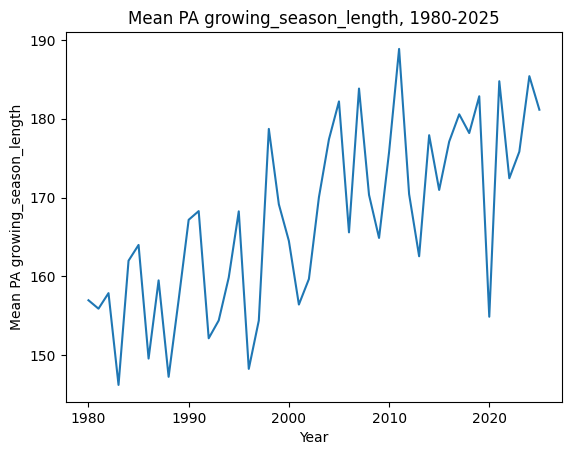

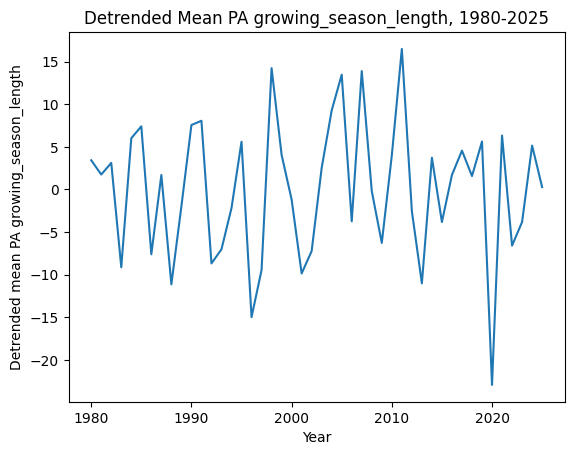

In [64]:
detrend_data(pa_gs, 'PA', 'growing_season_length', 'linear', 1980, 2025)